# 周期股分析教程

本教程将带你深入了解**周期股分析**——价值投资中最容易被忽视、也最容易亏钱的领域。

传统估值方法（PE、DCF）在周期股上不仅失效，还会产生致命误导：周期高点时PE最低（看起来最便宜），周期低谷时PE最高（看起来最贵）。如果不理解周期，"低PE买入"可能正好买在最高点。

## 学习目标

1. 理解为什么传统估值方法在周期股上失效
2. 掌握周期位置的判断方法（多维度评分体系）
3. 学会周期调整后的估值方法（PB、标准化PE、FCF收益率、股息率）
4. 理解A股和美股周期股的不同投资策略
5. 使用 `valueinvest` 库对真实周期股进行完整分析

---

> 本教程使用 [ValueInvest](https://github.com/wangzhe3224/valueinvest) 库

## 一、什么是周期股？

周期股是指盈利随经济周期、行业周期大幅波动的公司。它们的共同特征：

- **盈利波动剧烈**：好年份赚得盆满钵满，差年份直接亏损
- **重资产**：固定资产占比高，产能扩张/收缩有滞后性
- **价格弹性大**：产品价格由供需决定，而非品牌溢价

### 典型周期行业

| 周期类型 | 代表行业 | 代表公司 |
|---------|---------|---------|
| 大宗商品 | 煤炭、钢铁、有色 | 中国神华、宝钢股份 |
| 产能周期 | 化工、水泥、造纸 | 万华化学、海螺水泥 |
| 航运周期 | 集装箱、干散货 | 中远海控、中远海能 |
| 金融周期 | 银行、保险 | 招商银行、中国平安 |
| 地产周期 | 房地产开发 | 万科、保利发展 |
| 能源周期 | 油气、新能源 | 中国石油、隆基绿能 |

## 二、为什么传统估值方法会失效？

### "PE陷阱"：最危险的估值错觉

周期股最大的陷阱就是**低PE买入**。来看一个典型的周期：

```
周期位置:  低谷 → 复苏 → 繁荣 → 高峰 → 衰退 → 萧条
股价走势:  低   → 上涨 →  高   →  最高 → 下跌 →  低
每股收益:  低/负 → 恢复 → 极高  →  最高 → 暴跌 → 低/负
PE估值:    高/∞ → 中等 →  低    → 最低  → 升高  → 高/∞
          (便宜?)  (合理)  (便宜!) (捡到?) (变贵)  (昂贵)
```

**关键洞察**：
- 周期**高点**时 PE 最低 → 看起来最便宜 → 实际上最危险
- 周期**低谷**时 PE 最高（甚至为负）→ 看起来最贵 → 实际上是买入机会

### DCF 在周期股上的问题

DCF 假设未来盈利**稳定增长**，但周期股的盈利是**脉冲式**的：
- 用高峰期的盈利做 DCF → 严重高估
- 用低谷期的盈利做 DCF → 严重低估
- 用平均盈利做 DCF → 忽略了周期的位置信息

/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1576327301.py:40: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1576327301.py:40: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1576327301.py:40: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1576327301.py:40: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1576327301.py:40: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n6/83bf

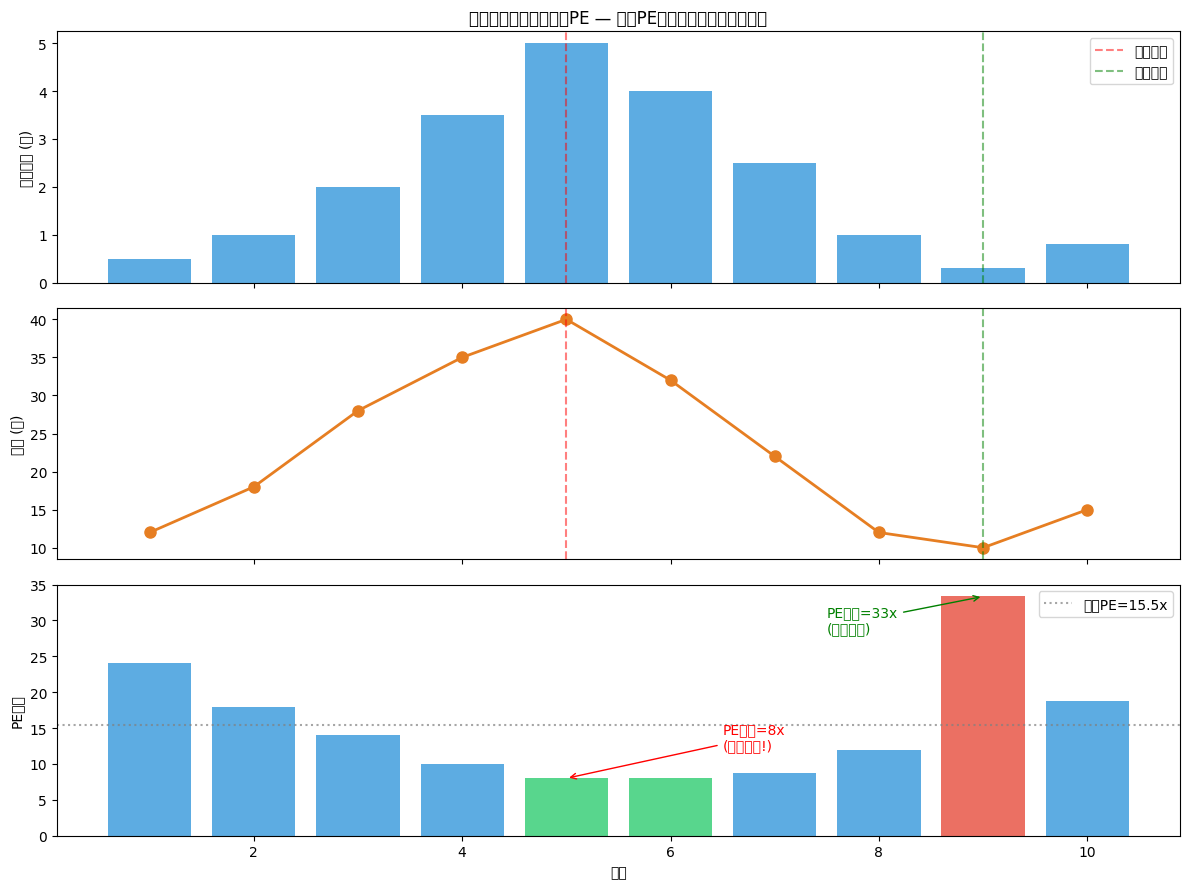

In [1]:
# 让我们用数据直观感受PE陷阱
import numpy as np
import matplotlib.pyplot as plt

# 模拟一个典型的10年周期
years = np.arange(1, 11)
# 盈利周期：低谷-复苏-繁荣-高峰-衰退-萧条
eps = [0.5, 1.0, 2.0, 3.5, 5.0, 4.0, 2.5, 1.0, 0.3, 0.8]
# 股价提前反应
price = [12, 18, 28, 35, 40, 32, 22, 12, 10, 15]
# PE
pe = [p/e for p, e in zip(price, eps)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

colors = ['#e74c3c' if p == max(pe) else '#2ecc71' if p == min(pe) else '#3498db' for p in pe]

axes[0].bar(years, eps, color='#3498db', alpha=0.8)
axes[0].set_ylabel('每股收益 (元)')
axes[0].set_title('周期股的盈利、股价与PE — 注意PE最低点对应的是什么位置')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.5, label='周期高点')
axes[0].axvline(x=9, color='green', linestyle='--', alpha=0.5, label='周期低谷')
axes[0].legend()

axes[1].plot(years, price, 'o-', color='#e67e22', linewidth=2, markersize=8)
axes[1].set_ylabel('股价 (元)')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=9, color='green', linestyle='--', alpha=0.5)

axes[2].bar(years, pe, color=colors, alpha=0.8)
axes[2].axhline(y=np.mean(pe), color='gray', linestyle=':', alpha=0.7, label=f'平均PE={np.mean(pe):.1f}x')
axes[2].set_ylabel('PE倍数')
axes[2].set_xlabel('年份')
axes[2].legend()
axes[2].annotate('PE最低=8x\n(周期高点!)', xy=(5, min(pe)), xytext=(6.5, min(pe)+4),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
axes[2].annotate('PE最高=33x\n(周期低谷)', xy=(9, max(pe)), xytext=(7.5, max(pe)-5),
                arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

plt.tight_layout()
plt.show()

上图清楚地展示了：**第5年周期高点时PE最低（8x），第9年周期低谷时PE最高（33x）**。如果你用"低PE = 便宜"的逻辑，会在最该卖出的时候买入。

## 三、周期股的正确估值方法

### 核心原则：先判周期位置，再做估值

周期股估值三步走：

```
第一步: 判断周期位置 → 我们在周期的哪个阶段？
第二步: 选择估值方法 → 根据周期阶段调整估值参数
第三步: 制定投资策略 → 买入/持有/卖出
```

### 估值方法选择

| 方法 | 核心逻辑 | 适用场景 | 优势 |
|------|---------|---------|------|
| **周期调整PB** | PB相对稳定，用历史分位数判断 | 大多数周期股 | 不受盈利波动影响 |
| **标准化PE** | 用3-5年平均EPS计算PE | 有稳定盈利历史的公司 | 消除单年异常 |
| **FCF收益率** | FCF比净利润更难操纵 | 现金流好的公司 | 质量更高 |
| **股息率** | 分红是真金白银 | 有稳定分红的公司 | 下行保护 |

## 四、环境准备

加载必要的库和数据。

In [2]:
import sys
sys.path.insert(0, '/Users/zhewang/Projects/2026/valueinvest-ws/valueinvest')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("环境准备完成 ✓")

环境准备完成 ✓


## 五、获取真实数据

以**中远海控（601919）**为例，它是航运周期的典型代表。2021年因集装箱运价暴涨，净利润超过1000亿元；而2019年净利润仅67亿元——盈利波动超过15倍。

In [3]:
from valueinvest.stock import Stock
from valueinvest.cyclical import (
    CyclicalAnalysisEngine, CyclicalStock, CycleType, CycleStrength,
    CyclePositionScorer, CycleIndicator, IndicatorCategory,
    CyclicalPBValuation, CyclicalPEValuation, CyclicalFCFValuation, CyclicalDividendValuation,
    AShareCyclicalStrategy
)

# 从API获取股票数据
stock = Stock.from_api("601919")
print(f"公司: {stock.name}")
print(f"当前价格: {stock.current_price:.2f} 元")
print(f"PE: {stock.pe_ratio:.2f}x")
print(f"PB: {stock.pb_ratio:.2f}x")
print(f"每股收益: {stock.eps:.4f} 元")
print(f"每股净资产: {stock.bvps:.4f} 元")
print(f"市值: {stock.market_cap:.0f} 亿元")

公司: 中远海控
当前价格: 14.45 元
PE: 7.26x
PB: 0.95x
每股收益: 1.9900 元
每股净资产: 15.1682 元
市值: 221268335618 亿元


In [4]:
# 将 Stock 转换为 CyclicalStock
# 中远海控属于航运周期
cyclical_stock = CyclicalStock.from_stock(
    stock=stock,
    cycle_type=CycleType.SHIPPING,
    cycle_strength=CycleStrength.STRONG
)

print(f"周期类型: {cyclical_stock.cycle_type}")
print(f"周期强度: {cyclical_stock.cycle_strength}")
print(f"市场: {cyclical_stock.market}")
print(f"当前PB: {cyclical_stock.pb:.2f}x")
print(f"ROE: {cyclical_stock.roe:.2%}")
print(f"股息率: {cyclical_stock.dividend_yield:.2%}")

周期类型: CycleType.SHIPPING
周期强度: CycleStrength.STRONG
市场: MarketType.A_SHARE
当前PB: 0.95x
ROE: 0.00%
股息率: 0.00%


## 六、一步完成分析（CyclicalAnalysisEngine）

`CyclicalAnalysisEngine` 提供了一站式分析：自动完成周期定位、多维估值、策略生成。适合快速获得整体判断。

In [5]:
# 使用分析引擎一步完成
engine = CyclicalAnalysisEngine()
result = engine.analyze(cyclical_stock)

print(f"{'='*50}")
print(f"  {result.stock.name} 周期股分析报告")
print(f"{'='*50}")
print(f"\n📊 周期位置: {result.cycle_analysis.phase_display}")
print(f"   综合评分: {result.cycle_analysis.total_score:.1f}/5.0")
print(f"   置信度: {result.cycle_analysis.confidence}")

print(f"\n📈 投资评级: {result.investment_rating}")
print(f"   总分: {result.overall_score:.0f}/100")
print(f"   风险等级: {result.risk_level}")

print(f"\n💰 策略建议: {result.strategy_recommendation.action_display}")
print(f"   目标价格: {result.strategy_recommendation.target_price:.2f} 元")
print(f"   止损价格: {result.strategy_recommendation.stop_loss_price:.2f} 元")
print(f"   预期收益: {result.strategy_recommendation.expected_return:.1%}")
print(f"   建议仓位: {result.strategy_recommendation.target_allocation:.0%}")
print(f"   持有周期: {result.strategy_recommendation.holding_period}")

  中远海控 周期股分析报告

📊 周期位置: 上行中期
   综合评分: 2.8/5.0
   置信度: Low

📈 投资评级: 谨慎
   总分: 34/100
   风险等级: 中

💰 策略建议: 持有
   目标价格: 22.75 元
   止损价格: 10.62 元
   预期收益: 5745.5%
   建议仓位: 5%
   持有周期: 1-3年


In [6]:
# 查看各维度估值结果
print("\n" + "="*50)
print("  多维度估值结果")
print("="*50)

for method_name, val_result in result.valuation_results.items():
    print(f"\n【{method_name}】")
    print(f"  公允价值: {val_result.fair_value:.2f} 元")
    print(f"  当前价格: {val_result.current_value:.2f} 元")
    print(f"  溢价/折价: {val_result.premium_discount:+.1%}")
    print(f"  安全边际: {val_result.margin_of_safety:.1%}")
    print(f"  评估: {val_result.assessment}")
    print(f"  置信度: {val_result.confidence}")


  多维度估值结果

【cyclical_pb】
  公允价值: 30.34 元
  当前价格: 14.45 元
  溢价/折价: +10994.0%
  安全边际: 5236.7%
  评估: Undervalued
  置信度: Low

【cyclical_pe】
  公允价值: 29.85 元
  当前价格: 14.45 元
  溢价/折价: +10657.4%
  安全边际: 5159.1%
  评估: Undervalued
  置信度: Medium

【cyclical_fcf】
  公允价值: 19.15 元
  当前价格: 14.45 元
  溢价/折价: +3254.9%
  安全边际: 2455.6%
  评估: Undervalued
  置信度: Low

【cyclical_dividend】
  公允价值: 0.00 元
  当前价格: 14.45 元
  溢价/折价: +0.0%
  安全边际: 0.0%
  评估: N/A
  置信度: N/A


In [7]:
# 查看买入清单
print("\n" + "="*50)
print("  买入条件检查")
print("="*50)
checklist = result.buy_checklist
print(f"通过: {checklist.passed_count}/{checklist.total_count} ({checklist.pass_rate:.0%})")
print()
for item, passed in checklist.items.items():
    status = "✅" if passed else "❌"
    print(f"  {status} {item}")


  买入条件检查
通过: 3/7 (4286%)

  ❌ 周期位置
  ✅ 估值安全
  ✅ 资产质量
  ❌ 现金流
  ❌ 分红能力
  ❌ ROE水平
  ✅ 历史PB低位


In [8]:
# 风险与催化剂
print("\n" + "="*50)
print("  风险因素")
print("="*50)
for i, risk in enumerate(result.risks, 1):
    print(f"  {i}. {risk}")

print(f"\n{'='*50}")
print("  积极催化剂")
print("="*50)
for i, catalyst in enumerate(result.catalysts, 1):
    print(f"  {i}. {catalyst}")


  风险因素
  1. 现金流质量差，盈利可能虚高

  积极催化剂
  1. 周期即将反转，布局良机
  2. PB < 1.0，安全边际极高


## 七、手动拆解：周期位置评分

接下来手动构建周期评分，理解引擎背后的逻辑。

`CyclePositionScorer` 从四个维度评估周期位置：

| 维度 | 权重(A股) | 说明 |
|------|----------|------|
| 估值指标 | 30% | PB、PE的历史分位数 |
| 财务指标 | 20% | ROE、利润率、FCF质量 |
| 行业指标 | 35% | 产能利用率、价格趋势 |
| 市场情绪 | 15% | 资金流向、分析师预期 |

In [9]:
# 手动构建周期评分
from valueinvest.cyclical import CyclePositionScorer, CycleIndicator, IndicatorCategory, MarketType

scorer = CyclePositionScorer(market=MarketType.A_SHARE)

# 添加估值指标
scorer.add_indicator(CycleIndicator(
    name="PB分位数",
    value=cyclical_stock.pb,
    category=IndicatorCategory.VALUATION,
    historical_avg=np.mean(cyclical_stock.historical_pb) if cyclical_stock.historical_pb else cyclical_stock.pb,
    percentile=30,  # 假设当前PB处于历史30%分位
    trend="stable",
    weight=0.5,
    unit="x",
    description="当前PB相对历史水平",
    historical_values=cyclical_stock.historical_pb or [cyclical_stock.pb]
))

scorer.add_indicator(CycleIndicator(
    name="PE分位数",
    value=cyclical_stock.pe,
    category=IndicatorCategory.VALUATION,
    historical_avg=np.mean(cyclical_stock.historical_pe) if cyclical_stock.historical_pe else cyclical_stock.pe,
    percentile=25,
    trend="down",
    weight=0.5,
    unit="x",
    description="当前PE相对历史水平",
    historical_values=cyclical_stock.historical_pe or [cyclical_stock.pe]
))

# 添加财务指标
scorer.add_indicator(CycleIndicator(
    name="ROE",
    value=cyclical_stock.roe * 100,
    category=IndicatorCategory.FINANCIAL,
    historical_avg=12.0,
    percentile=40,
    trend="stable",
    weight=0.4,
    unit="%",
    description="净资产收益率",
    historical_values=cyclical_stock.historical_roe or [cyclical_stock.roe * 100]
))

scorer.add_indicator(CycleIndicator(
    name="毛利率",
    value=cyclical_stock.gross_margin * 100,
    category=IndicatorCategory.FINANCIAL,
    weight=0.3,
    unit="%",
    description="毛利率",
    historical_values=[cyclical_stock.gross_margin * 100]
))

scorer.add_indicator(CycleIndicator(
    name="FCF/净利润",
    value=cyclical_stock.fcf_to_net_income * 100,
    category=IndicatorCategory.FINANCIAL,
    weight=0.3,
    unit="%",
    description="现金流质量",
    historical_values=[cyclical_stock.fcf_to_net_income * 100]
))

# 添加行业指标
scorer.add_indicator(CycleIndicator(
    name="运价指数",
    value=1200,
    category=IndicatorCategory.INDUSTRY,
    historical_avg=1500,
    percentile=35,
    trend="down",
    weight=0.5,
    unit="点",
    description="SCFI集装箱运价指数",
    historical_values=[1200, 1500, 2000, 3500, 4000, 3000, 1800]
))

scorer.add_indicator(CycleIndicator(
    name="新船订单/运力",
    value=8.5,
    category=IndicatorCategory.INDUSTRY,
    historical_avg=10.0,
    percentile=40,
    trend="down",
    weight=0.5,
    unit="%",
    description="新船订单占现有运力比例",
    historical_values=[8.5, 10.0, 12.0, 15.0]
))

# 计算评分
cycle_score = scorer.calculate_score()

print(f"{'='*50}")
print(f"  周期位置评分结果")
print(f"{'='*50}")
print(f"\n{cycle_score.phase_emoji} 周期阶段: {cycle_score.phase_display}")
print(f"   综合评分: {cycle_score.total_score:.2f}/5.0")
print(f"   置信度: {cycle_score.confidence}")
print(f"\n   评估: {cycle_score.assessment}")

print(f"\n--- 各维度评分 ---")
print(f"   估值维度: {cycle_score.valuation_score:.2f}/5.0")
print(f"   财务维度: {cycle_score.financial_score:.2f}/5.0")
print(f"   行业维度: {cycle_score.industry_score:.2f}/5.0")
print(f"   情绪维度: {cycle_score.sentiment_score:.2f}/5.0")

  周期位置评分结果

⬆️ 周期阶段: 上行中期
   综合评分: 2.53/5.0
   置信度: Low

   评估: 上行初期，逐步建仓

--- 各维度评分 ---
   估值维度: 2.00/5.0
   财务维度: 3.00/5.0
   行业维度: 2.50/5.0
   情绪维度: 3.00/5.0


In [10]:
# 查看各指标详细状态
print("\n--- 各指标状态 ---")
for indicator in cycle_score.indicators:
    bar_len = int(indicator.score)
    bar = "█" * bar_len + "░" * (5 - bar_len)
    print(f"  [{bar}] {indicator.name}: {indicator.score:.1f}/5.0 ({indicator.status})")
    print(f"       当前值: {indicator.value:.1f}{indicator.unit} | 历史均值: {indicator.historical_avg:.1f}{indicator.unit} | 分位: {indicator.percentile:.0f}%")

print(f"\n--- 分析依据 ---")
for rationale in cycle_score.rationale:
    print(f"  • {rationale}")


--- 各指标状态 ---
  [██░░░] PB分位数: 2.0/5.0 (偏低)
       当前值: 1.0x | 历史均值: 1.0x | 分位: 30%
  [██░░░] PE分位数: 2.0/5.0 (偏低)
       当前值: 7.3x | 历史均值: 7.3x | 分位: 25%
  [███░░] ROE: 3.0/5.0 (中等)
       当前值: 0.0% | 历史均值: 12.0% | 分位: 40%
  [███░░] 毛利率: 3.0/5.0 (中等)
       当前值: 0.0% | 历史均值: 0.0% | 分位: 50%
  [███░░] FCF/净利润: 3.0/5.0 (中等)
       当前值: 66.5% | 历史均值: 0.0% | 分位: 50%
  [██░░░] 运价指数: 2.0/5.0 (偏低)
       当前值: 1200.0点 | 历史均值: 1500.0点 | 分位: 35%
  [███░░] 新船订单/运力: 3.0/5.0 (中等)
       当前值: 8.5% | 历史均值: 10.0% | 分位: 40%

--- 分析依据 ---
  • 估值偏低，具有一定安全边际
  • 行业景气度偏低，供需关系改善中


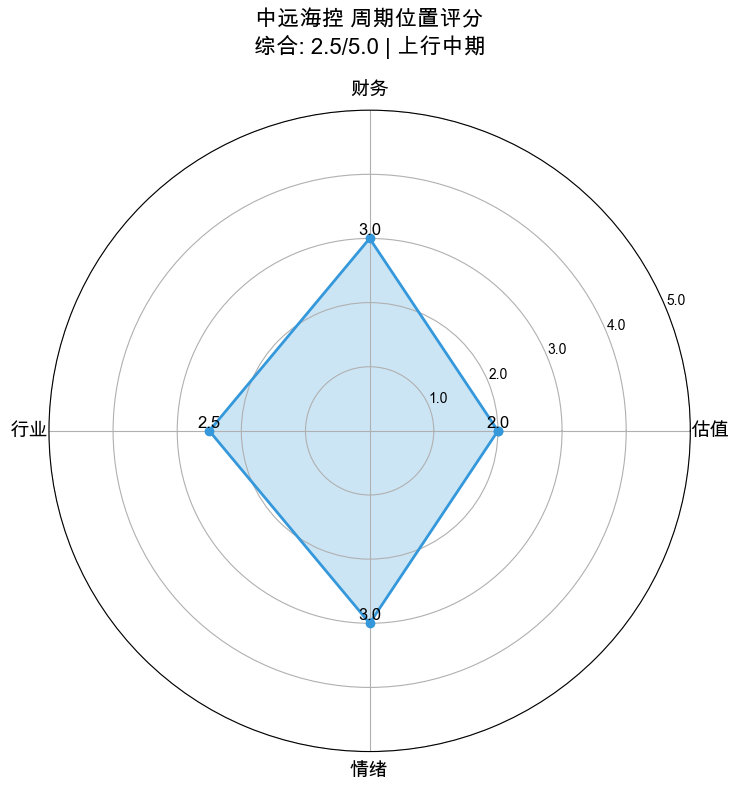

In [11]:
# 可视化周期评分雷达图
categories = ['估值', '财务', '行业', '情绪']
scores = [
    cycle_score.valuation_score,
    cycle_score.financial_score,
    cycle_score.industry_score,
    cycle_score.sentiment_score
]

# 雷达图
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
scores_plot = scores + [scores[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, scores_plot, alpha=0.25, color='#3498db')
ax.plot(angles, scores_plot, 'o-', linewidth=2, color='#3498db')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=14)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1.0', '2.0', '3.0', '4.0', '5.0'])

for angle, score, cat in zip(angles[:-1], scores, categories):
    ax.annotate(f'{score:.1f}', xy=(angle, score), fontsize=12, fontweight='bold',
                ha='center', va='bottom')

ax.set_title(f'{cyclical_stock.name} 周期位置评分\n综合: {cycle_score.total_score:.1f}/5.0 | {cycle_score.phase_display}',
             fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 八、手动拆解：四种估值方法

分别用四种方法对周期股估值，理解每种方法的逻辑和适用场景。

### 8.1 周期调整PB估值

PB是周期股最可靠的估值指标，因为：
- 净资产相对稳定，不像盈利那样大幅波动
- 周期低谷时PB最低，是较好的买入信号
- 不同周期阶段使用不同的PB阈值

In [12]:
pb_valuation = CyclicalPBValuation()
pb_result = pb_valuation.calculate(cyclical_stock)

print(f"{'='*50}")
print(f"  周期调整PB估值")
print(f"{'='*50}")
print(f"\n当前PB: {cyclical_stock.pb:.2f}x")
print(f"每股净资产: {cyclical_stock.bvps:.2f} 元")
print(f"\n公允价值: {pb_result.fair_value:.2f} 元")
print(f"溢价/折价: {pb_result.premium_discount:+.1%}")
print(f"安全边际: {pb_result.margin_of_safety:.1%}")
print(f"评估: {pb_result.assessment}")
print(f"建议操作: {pb_result.action}")
print(f"置信度: {pb_result.confidence}")

if pb_result.details:
    print(f"\n--- 估值细节 ---")
    for key, value in pb_result.details.items():
        print(f"  {key}: {value}")

  周期调整PB估值

当前PB: 0.95x
每股净资产: 15.17 元

公允价值: 30.34 元
溢价/折价: +10994.0%
安全边际: 5236.7%
评估: Undervalued
建议操作: STRONG_BUY
置信度: Low

--- 估值细节 ---
  current_pb: 0.9526533340107226
  fair_pb: 2.0
  bvps: 15.168161894909568
  cycle_phase: mid_upside
  buy_threshold: 1.5
  hold_threshold: 2.0
  sell_threshold: 2.5
  historical_pb_avg: None
  historical_pb_median: None


### 8.2 标准化PE估值

用过去3-5年的平均EPS来计算PE，消除单年异常盈利的影响。

In [13]:
pe_valuation = CyclicalPEValuation()
pe_result = pe_valuation.calculate(cyclical_stock)

print(f"{'='*50}")
print(f"  标准化PE估值")
print(f"{'='*50}")
print(f"\n当前PE: {cyclical_stock.pe:.2f}x")
print(f"每股收益: {cyclical_stock.eps:.4f} 元")
print(f"\n公允价值: {pe_result.fair_value:.2f} 元")
print(f"溢价/折价: {pe_result.premium_discount:+.1%}")
print(f"安全边际: {pe_result.margin_of_safety:.1%}")
print(f"评估: {pe_result.assessment}")
print(f"建议操作: {pe_result.action}")
print(f"置信度: {pe_result.confidence}")

if pe_result.details:
    print(f"\n--- 估值细节 ---")
    for key, value in pe_result.details.items():
        print(f"  {key}: {value}")

  标准化PE估值

当前PE: 7.26x
每股收益: 1.9900 元

公允价值: 29.85 元
溢价/折价: +10657.4%
安全边际: 5159.1%
评估: Undervalued
建议操作: STRONG_BUY
置信度: Medium

--- 估值细节 ---
  current_pe: 7.261306532663316
  cyclical_adjusted_pe: 7.261306532663316
  cyclical_adjusted_eps: 1.99
  current_eps: 1.99
  fair_pe: 15.0
  buy_threshold: 12.0
  sell_threshold: 20.0
  pe_adjustment_factor: 1.0


### 8.3 FCF收益率估值

自由现金流比净利润更难操纵，对周期股尤为重要。

In [14]:
fcf_valuation = CyclicalFCFValuation()
fcf_result = fcf_valuation.calculate(cyclical_stock)

print(f"{'='*50}")
print(f"  FCF收益率估值")
print(f"{'='*50}")
print(f"\nFCF收益率: {cyclical_stock.fcf_yield:.2%}")
print(f"FCF/净利润: {cyclical_stock.fcf_to_net_income:.2f}x")
print(f"\n公允价值: {fcf_result.fair_value:.2f} 元")
print(f"溢价/折价: {fcf_result.premium_discount:+.1%}")
print(f"安全边际: {fcf_result.margin_of_safety:.1%}")
print(f"评估: {fcf_result.assessment}")
print(f"建议操作: {fcf_result.action}")
print(f"置信度: {fcf_result.confidence}")

if fcf_result.details:
    print(f"\n--- 估值细节 ---")
    for key, value in fcf_result.details.items():
        print(f"  {key}: {value}")

  FCF收益率估值

FCF收益率: 9.28%
FCF/净利润: 0.67x

公允价值: 19.15 元
溢价/折价: +3254.9%
安全边际: 2455.6%
评估: Undervalued
建议操作: SELL
置信度: Low

--- 估值细节 ---
  fcf_yield: 0.09278426015795331
  fair_fcf_yield: 7.0
  fcf_per_share: 1.3407325592824253
  fcf_to_net_income: 0.6650939646741711
  fcf_quality: Poor
  buy_threshold: 10.0
  sell_threshold: 5.0


### 8.4 股息率估值

分红是真金白银，周期股在盈利高峰期通常有丰厚的分红，可以作为安全边际的参考。

In [15]:
div_valuation = CyclicalDividendValuation()
div_result = div_valuation.calculate(cyclical_stock)

print(f"{'='*50}")
print(f"  股息率估值")
print(f"{'='*50}")
print(f"\n股息率: {cyclical_stock.dividend_yield:.2%}")
print(f"分红率: {cyclical_stock.payout_ratio:.2%}")
print(f"连续分红年数: {cyclical_stock.consecutive_dividend_years} 年")
print(f"\n公允价值: {div_result.fair_value:.2f} 元")
print(f"溢价/折价: {div_result.premium_discount:+.1%}")
print(f"安全边际: {div_result.margin_of_safety:.1%}")
print(f"评估: {div_result.assessment}")
print(f"建议操作: {div_result.action}")
print(f"置信度: {div_result.confidence}")

if div_result.details:
    print(f"\n--- 估值细节 ---")
    for key, value in div_result.details.items():
        print(f"  {key}: {value}")

  股息率估值

股息率: 0.00%
分红率: 0.00%
连续分红年数: 0 年

公允价值: 0.00 元
溢价/折价: +0.0%
安全边际: 0.0%
评估: N/A
建议操作: ERROR
置信度: N/A

--- 估值细节 ---
  error: Dividend yield must be positive


## 九、四种估值方法对比

In [16]:
# 汇总四种估值结果
methods = {
    '周期调整PB': pb_result,
    '标准化PE': pe_result,
    'FCF收益率': fcf_result,
    '股息率': div_result,
}

print(f"{'='*70}")
print(f"  {cyclical_stock.name} 四维估值汇总")
print(f"  当前价格: {cyclical_stock.current_price:.2f} 元")
print(f"{'='*70}")
print(f"{'方法':<12} {'公允价值':>10} {'溢价/折价':>10} {'安全边际':>10} {'评估':<8} {'置信度':<6}")
print(f"{'-'*70}")

fair_values = []
for name, r in methods.items():
    print(f"{name:<12} {r.fair_value:>10.2f} {r.premium_discount:>+10.1%} {r.margin_of_safety:>10.1%} {r.assessment:<8} {r.confidence:<6}")
    fair_values.append(r.fair_value)

avg_fair_value = np.mean(fair_values)
print(f"{'-'*70}")
print(f"{'综合估值':<12} {avg_fair_value:>10.2f} {(avg_fair_value/cyclical_stock.current_price - 1):>+10.1%}")

  中远海控 四维估值汇总
  当前价格: 14.45 元
方法                 公允价值      溢价/折价       安全边际 评估       置信度   
----------------------------------------------------------------------
周期调整PB            30.34  +10994.0%    5236.7% Undervalued Low   
标准化PE             29.85  +10657.4%    5159.1% Undervalued Medium
FCF收益率            19.15   +3254.9%    2455.6% Undervalued Low   
股息率                0.00      +0.0%       0.0% N/A      N/A   
----------------------------------------------------------------------
综合估值              19.83     +37.3%


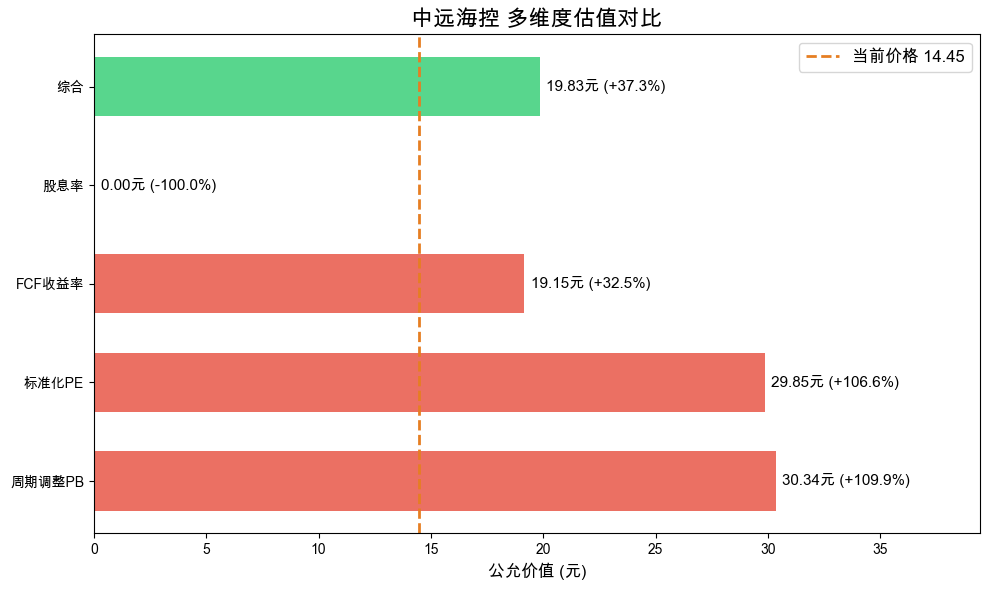

In [17]:
# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))

names = list(methods.keys()) + ['综合']
values = fair_values + [avg_fair_value]
colors_bar = ['#3498db' if v < cyclical_stock.current_price else '#e74c3c' for v in values]
colors_bar[-1] = '#2ecc71'  # 综合用绿色

bars = ax.barh(names, values, color=colors_bar, alpha=0.8, height=0.6)
ax.axvline(x=cyclical_stock.current_price, color='#e67e22', linestyle='--', linewidth=2, label=f'当前价格 {cyclical_stock.current_price:.2f}')

for bar, val in zip(bars, values):
    premium = (val / cyclical_stock.current_price - 1) * 100
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}元 ({premium:+.1f}%)', va='center', fontsize=11)

ax.set_xlabel('公允价值 (元)', fontsize=12)
ax.set_title(f'{cyclical_stock.name} 多维度估值对比', fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(0, max(values) * 1.3)
plt.tight_layout()
plt.show()

## 十、投资策略生成

A股周期股策略偏向**交易型**：利用周期波动获取超额收益。

与美股周期股策略（偏向分红防御型）有本质区别。

In [18]:
# A股周期股策略（使用引擎的完整分析结果）
strategy = AShareCyclicalStrategy()
recommendation = strategy.generate_recommendation(cyclical_stock, result)

print(f"{'='*50}")
print(f"  A股周期股投资策略")
print(f"{'='*50}")
print(f"\n{recommendation.action_signal} 操作建议: {recommendation.action_display}")
print(f"   策略类型: {recommendation.strategy_type}")
print(f"\n   目标价格: {recommendation.target_price:.2f} 元")
print(f"   止损价格: {recommendation.stop_loss_price:.2f} 元")
print(f"   预期收益: {recommendation.expected_return:.1%}")
print(f"   年化收益: {recommendation.expected_annual_return:.1%}")
print(f"   建议仓位: {recommendation.target_allocation:.0%}")
print(f"   持有周期: {recommendation.holding_period}")
print(f"   股息率: {recommendation.dividend_yield:.2%}")

print(f"\n--- 投资依据 ---")
for r in recommendation.rationale:
    print(f"  • {r}")

  A股周期股投资策略

🟡 操作建议: 持有
   策略类型: InvestmentStrategy.CYCLICAL_TRADING

   目标价格: 22.75 元
   止损价格: 10.62 元
   预期收益: 5745.5%
   年化收益: 0.0%
   建议仓位: 5%
   持有周期: 1-3年
   股息率: 0.00%

--- 投资依据 ---
  • 周期阶段：上行中期
  • PB 0.95x，低于净资产，安全边际高
  • 负债率 41.4%，财务健康
  • 持有：等待周期进一步明朗


In [19]:
# 查看买卖清单
buy_list = strategy.get_buy_checklist(cyclical_stock)
sell_list = strategy.get_sell_checklist(cyclical_stock)

print(f"\n{'='*50}")
print(f"  买入条件")
print(f"{'='*50}")
for item, passed in buy_list.items.items():
    status = "✅" if passed else "❌"
    print(f"  {status} {item}")
print(f"\n通过率: {buy_list.pass_rate:.0%}")

print(f"\n{'='*50}")
print(f"  卖出条件")
print(f"{'='*50}")
for item, passed in sell_list.items.items():
    status = "⚠️" if passed else "—" 
    print(f"  {status} {item}")


  买入条件
  ❌ 周期位置
  ✅ 估值安全
  ✅ 资产质量
  ❌ 现金流
  ❌ 分红能力
  ❌ ROE水平
  ✅ 历史PB低位

通过率: 4286%

  卖出条件
  — 周期位置
  — 估值过高
  ⚠️ ROE恶化
  — 行业信号
  — 市场情绪


## 十一、多公司对比

用不同行业的周期股做对比，理解不同周期类型的特征。

In [20]:
# 对比不同行业的周期股
tickers = [
    ("601919", "中远海控", CycleType.SHIPPING, "航运"),
    ("601088", "中国神华", CycleType.COMMODITY, "煤炭"),
    ("600309", "万华化学", CycleType.CAPACITY, "化工"),
]

results = []
for ticker, name, cycle_type, industry in tickers:
    try:
        s = Stock.from_api(ticker)
        cs = CyclicalStock.from_stock(s, cycle_type=cycle_type)
        engine = CyclicalAnalysisEngine()
        r = engine.analyze(cs)
        results.append({
            'ticker': ticker,
            'name': name,
            'industry': industry,
            'price': cs.current_price,
            'pb': cs.pb,
            'pe': cs.pe,
            'roe': cs.roe,
            'dividend_yield': cs.dividend_yield,
            'cycle_phase': r.cycle_analysis.phase_display,
            'cycle_score': r.cycle_analysis.total_score,
            'overall_score': r.overall_score,
            'rating': r.investment_rating,
            'action': r.strategy_recommendation.action_display,
        })
    except Exception as e:
        print(f"{name} 分析失败: {e}")

df = pd.DataFrame(results)
df

,ticker,name,industry,price,pb,pe,roe,dividend_yield,cycle_phase,cycle_score,overall_score,rating,action
0,601919,中远海控,航运,14.45,0.952653,7.261307,0,0,上行中期,2.8,34.0,谨慎,持有
1,601088,中国神华,煤炭,46.98,2.490717,17.661654,0,0,上行中期,2.8,69.0,推荐,持有
2,600309,万华化学,化工,87.65,2.463090,73.655462,0,0,上行中期,2.8,59.0,中性,持有


/var/folders/n6/83bfjdl97n1f75gf862k5r7m0000gn/T/ipykernel_69316/1306472941.py:36: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


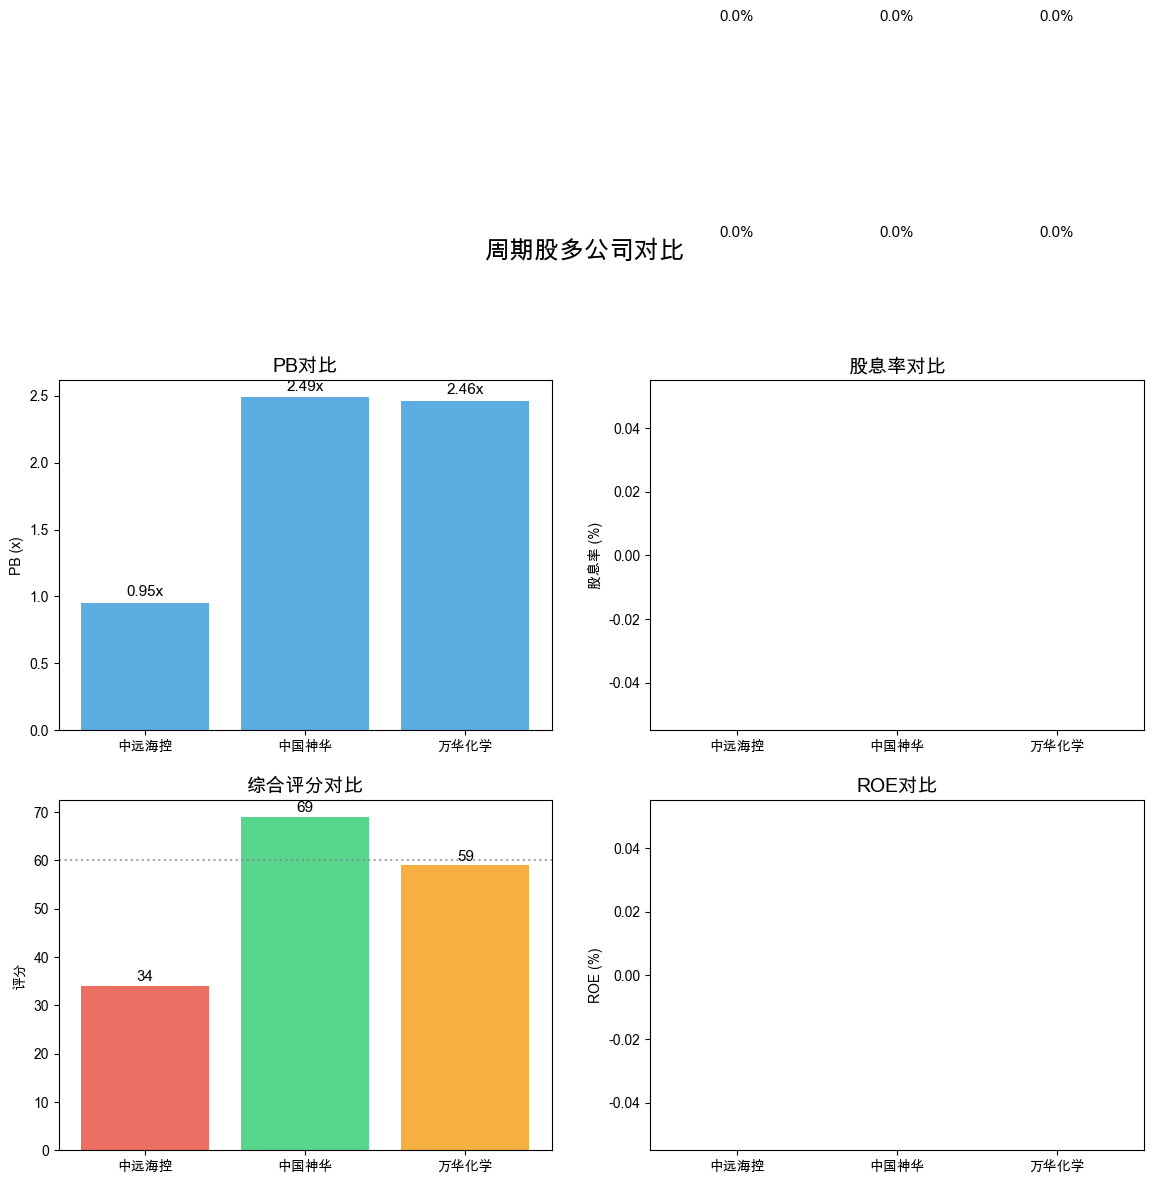

In [21]:
# 对比可视化
if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # PB对比
    axes[0, 0].bar(df['name'], df['pb'], color='#3498db', alpha=0.8)
    axes[0, 0].set_title('PB对比', fontsize=14)
    axes[0, 0].set_ylabel('PB (x)')
    for i, (v, name) in enumerate(zip(df['pb'], df['name'])):
        axes[0, 0].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=11)

    # 股息率对比
    axes[0, 1].bar(df['name'], df['dividend_yield'] * 100, color='#2ecc71', alpha=0.8)
    axes[0, 1].set_title('股息率对比', fontsize=14)
    axes[0, 1].set_ylabel('股息率 (%)')
    for i, (v, name) in enumerate(zip(df['dividend_yield'] * 100, df['name'])):
        axes[0, 1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=11)

    # 综合评分对比
    colors_score = ['#e74c3c' if s < 40 else '#f39c12' if s < 60 else '#2ecc71' for s in df['overall_score']]
    axes[1, 0].bar(df['name'], df['overall_score'], color=colors_score, alpha=0.8)
    axes[1, 0].set_title('综合评分对比', fontsize=14)
    axes[1, 0].set_ylabel('评分')
    axes[1, 0].axhline(y=60, color='gray', linestyle=':', alpha=0.7)
    for i, (v, name) in enumerate(zip(df['overall_score'], df['name'])):
        axes[1, 0].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=11)

    # ROE对比
    axes[1, 1].bar(df['name'], df['roe'] * 100, color='#9b59b6', alpha=0.8)
    axes[1, 1].set_title('ROE对比', fontsize=14)
    axes[1, 1].set_ylabel('ROE (%)')
    for i, (v, name) in enumerate(zip(df['roe'] * 100, df['name'])):
        axes[1, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

    plt.suptitle('周期股多公司对比', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

## 十二、A股 vs 美股周期股策略差异

In [22]:
# 策略对比表
comparison = pd.DataFrame({
    '维度': ['投资目标', '持有周期', '目标收益', '单只仓位上限', '周期股总仓位上限',
            '核心指标', '买入条件', '卖出信号'],
    'A股策略': ['交易型，追求超额收益', '1-3年', '50-200%', '10%', '35%',
              'PB分位数、周期位置', '周期低谷 + PB<1.2x', '周期高点 + PB>2.5x'],
    '美股策略': ['分红防御型，稳定收入', '5-10年', '6-10%/年', '8%', '25%',
              '股息率、FCF覆盖率', '连续分红5年+FCF>1.5x', '削减分红或FCF恶化']
})
comparison

,维度,A股策略,美股策略
0,投资目标,交易型，追求超额收益,分红防御型，稳定收入
1,持有周期,1-3年,5-10年
2,目标收益,50-200%,6-10%/年
3,单只仓位上限,10%,8%
4,周期股总仓位上限,35%,25%
5,核心指标,PB分位数、周期位置,股息率、FCF覆盖率
6,买入条件,周期低谷 + PB<1.2x,连续分红5年+FCF>1.5x
7,卖出信号,周期高点 + PB>2.5x,削减分红或FCF恶化


**核心区别**：

- **A股周期股**：利用周期波动做波段，在低谷买入、高峰卖出，追求高绝对收益
- **美股周期股**：通过分红获取稳定现金流，长期持有优质周期龙头，追求总回报

这种差异源于两个市场的制度特征：A股个人投资者占比高、波动大、分红文化弱；美股机构投资者占比高、波动相对小、分红文化强。

## 十三、总结与要点

### 周期股投资的核心原则

1. **先判周期，再做估值** — 不确定周期位置之前，所有估值都是空中楼阁
2. **低PE是陷阱，不是机会** — 周期高点PE最低，这是最危险的买入信号
3. **PB比PE更可靠** — 净资产比盈利稳定得多，用PB的历史分位数判断
4. **在别人恐惧时贪婪** — 周期低谷时PE最高、市场最悲观，反而是买入机会
5. **设定纪律性止盈** — 周期高点时不要贪心，严格执行卖出纪律

### 估值方法优先级

```
周期调整PB（首选）> 标准化PE > FCF收益率 > 股息率
```

### 常见错误

- ❌ 用高峰期盈利做DCF → 严重高估
- ❌ 因为"低PE"买入 → 买在最高点
- ❌ 用成长股的估值框架 → 忽略周期性
- ❌ 不设止盈 → 坐过山车

---

> 本教程使用 [ValueInvest](https://github.com/wangzhe3224/valueinvest) 库